# Datastrukturer: Lister
* I forrige time regnet vi på populasjonsvekst for Norge og Sverige
* Hva om vi i populasjonsveksteksempelet ikke bare så på 2 land, men kanskje alle i Europa
* Alle parametre måtte ha en egen variabel for hvert land
* Det fungerer dårlig -- i praksis må vi ha like mange variabler som datapunkt
* Det kan dreie seg om millioner av variabler å lage navn til å holde styr på
* **NEI TAKK**

## Lister
* Vi trenger en annen måte å organisere og *strukturere* datapunktene våre på
* Python har flere ulike typer **datastrukturer** som kan hjelpe oss med det
* Den første vi skal se på er *lister*

* Vi lager lister med ting ved å «liste de opp» inne i klammeparanteser (alt + shift 8 og 9 på mac ?)
* Listene kan inneholde alle hva som helst, til og med funksjoner, og vi kan blande datatyper

In [2]:
#De kan inneholde alt mulig, til og med funksjoner
a = ["hei", 22, 4e6, print]
print(a)
print(type(a))
print(dir(a))

['hei', 22, 4000000.0, <built-in function print>]
<class 'list'>
['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__iadd__', '__imul__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__rmul__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'append', 'clear', 'copy', 'count', 'extend', 'index', 'insert', 'pop', 'remove', 'reverse', 'sort']


* For å hente ut et element i listen bruker oppgir vi *indeksen* til elementet i klammeparanteser

In [3]:
#Element3
print(a)
a[2]

['hei', 22, 4000000.0, <built-in function print>]


4000000.0

In [4]:
#Element 1
a[0]

'hei'

* Merk at listene er «0-indeksert», vi teller altså fra og med 0 og oppover
* Noen datatyper er det ulovlig å endre innholdet av, men med lister kan vi det

In [5]:
a[2] = 2+2 #Vi endrer element nr 3, som har indeks 2
a[0] = 42 #Vi endrer første element
a[-1] = 2**4 #Dersom vi bruker negative indekser, "begynner" vi på slutten av listen
print(a)

[42, 22, 4, 16]


* Vi kan bruke dir() for å se nyttige innebygde funksjoner av listen
* Disse kan kalles med '.' feks `min_liste.sort()` for å sortere listen i stigende rekkefølge


In [6]:
print(a)
a.sort()
print("sortert", a)
#Fjern siste element og lagre i variabel
siste = a.pop()
print("siste", siste, "\nRest", a)

[42, 22, 4, 16]
sortert [4, 16, 22, 42]
siste 42 
Rest [4, 16, 22]


In [7]:
#Legg til et element på slutten:
a.append(3.14)
print(a)


[4, 16, 22, 3.14]


In [8]:
# "Pop" første element
first = a.pop(0)
print("Første:", first, "\nRest", a)

Første: 4 
Rest [16, 22, 3.14]


* Andre viktige funksjoner er `len(«liste»)` og `max(«liste»)`

In [9]:
print("Lengden på liste a er:", len(a))
print("Største element er:", max(a))

Lengden på liste a er: 3
Største element er: 22


## Eks: Populasjonsvekst - Skandinavia
* Samme eksempel som tidligere, men vi ser på hele skandinavia

In [10]:
import math
land = ["Norge", "Sverige", "Danmark"]
K = [20e6, 25e6, 15e6] #Makspopulasjon
r = [0.01, 0.02, 0.03] #relativ vekstrate
P0 = [4e6, 8e6, 6e6] # Startpopulasjon
t = 20 #Hvor mange år vekst


def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P
  
def lag_pop_funk(P0,K,r):
    def slutt_populasjon(t):
        P = logistisk_vekst(P0,K,r,t)
        return P
    return slutt_populasjon #Vi returnerer funksjonen vi laget inne i funksjonen!

def format_pop(P):
    return int(round(P,-3))

pop_funksjoner = [] #Liste med funksjoner som regner ut populasjon ved tiden t for land 0,1,2
pop_funksjoner.append( lag_pop_funk(P0[0], K[0], r[0]))
pop_funksjoner.append(lag_pop_funk(P0[1], K[1], r[1]))
pop_funksjoner.append(lag_pop_funk(P0[2], K[2], r[2]))
#Vi kunne også lagret disse funksjonene i en liste.. :)

#print(type(pop_norge))
P_slutt = []
P_slutt.append(pop_funksjoner[0](t))
P_slutt.append(pop_funksjoner[1](t))
P_slutt.append(pop_funksjoner[2](t))

print("Sluttpopulasjonen i", land[0], "er:", format_pop(P_slutt[0]))
print("Sluttpopulasjonen i", land[1], "er:", format_pop(P_slutt[1]))
print("Sluttpopulasjonen i", land[2], "er:", format_pop(P_slutt[2]))


Sluttpopulasjonen i Norge er: 4678000
Sluttpopulasjonen i Sverige er: 10312000
Sluttpopulasjonen i Danmark er: 8227000


# Fortsatt problemer?
* Vi har samlet dataene vår i lister -- det er bra
* Men vi må fortsatt gå igjennom disse listene for hånd -- ikke bra
* Vi trenger en måte å gå gjennom lister og andre datastrukturer *automatisk*

# Løkker: `for`-løkken
* I programmering trenger vi ofte å gjenta ca. samme operasjon mange ganger
* Vi kan da lage det som kalles en løkke, eller *loop* på engelsk
* Løkken består av kode som vi kjører om igjen mange ganger
* Hver runde gjennom løkken kalles en *iterasjon*
* Dersom må har en løkke som gjør noe for alle elementene i en liste `a` sier man at man *itererer* over listen



* Vi har to metoder for å gjenta ting mange ganger i python:
  - `for`-løkken (for-loop)
  - `while`-løkken
* I en `for` løkke gjør vi noe «for» alle elementene i en samling elementer man kan *iterere* over
* Syntaksen er som følger:

```python
for element in samling_elementer:
    #Gjør noe med elementene
    print("Elementet er ", element)
#Løkke ferdig
```

* «element» er her et variabelnavn for enkeltelementene i samlingen.
* Vi kan gi det hvilket som helst gyldig navn som `i, j, x, y, datapunkt, person ...` osv
* Dersom vi gir det navnet `_` (nedestrek) går vi igjennom datasamlingen uten å bry oss om enkeltelementet

In [13]:
#Print ut innholdet i listen a ett element om gangen
for tall in a:
    print(tall)

16
22
3.14


* Når man skal bygge og fylle en liste med data er det vanlig å starte med en tom liste feks `b=[]`
* Deretter iterere over noen annen data en bruker til å fylle listen med `b.append(«nytt datapunkt»)`

In [17]:
# Lag en liste b hvor elementene er dobbelt av de i a:
a = [1,2,3,4,5]
b = []
for tall in a:
    dobbelt = tall*2
    b.append(dobbelt)
print(b)

10
[2, 4, 6, 8, 10]


In [19]:
%%html
<iframe width="800" height="500" frameborder="0" src="https://pythontutor.com/iframe-embed.html#code=%23%20Lag%20en%20liste%20b%20hvor%20elementene%20er%20dobbelt%20av%20de%20i%20a%3A%0Aa%20%3D%20%5B1,2,3,4,5%5D%0Ab%20%3D%20%5B%5D%0Afor%20tall%20in%20a%3A%0A%20%20%20%20dobbelt%20%3D%20tall*2%0A%20%20%20%20b.append%28dobbelt%29%0Aprint%28b%29&codeDivHeight=400&codeDivWidth=350&cumulative=false&curInstr=19&heapPrimitives=nevernest&origin=opt-frontend.js&py=3&rawInputLstJSON=%5B%5D&textReferences=false"> </iframe>

* Ofte må man ha kontroll på både elementene i listen, og indeksen til listen
* Da er det vanlig å ikke iterere over selve elementene, men over *indeksområdet* (index range på engelsk)
* Til det bruker man en meget nyttig funksjon `range(..)`
* *Merk:* om man vil liste opp indeksområdet kan man bruke funksjonen `list(«noe itererbart»)` som tar noe man kan iterere over (gå igjennom elementvis) og lager en liste av elementene

In [35]:
#range(«stop») gir en "range" fra 0 til (men ikke med) «stop»
print(list(range(10)))
#range(«start», «stop») gir en "range" fra «start» til (men ikke med) «stop»
print(list(range(3,10)))
#range(«start», «stop», «step»)  gir en "range" fra «start» til (men ikke med) «stop» med steglengde «step»
print(list(range(1,10,2)))


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[3, 4, 5, 6, 7, 8, 9]
[1, 3, 5, 7, 9]


In [41]:
#Doble elementene i listen a
a = [1,2,3,4,5]
n = len(a) #len(«liste») gir lengden på listen
for i in range(n):
    a[i] = a[i]*2 #Man kan fint oppdatere en variabel eller et liste-element via sin nåværende verdi
print(a)

[2, 4, 6, 8, 10]


## Nyttige litt mer avanserte teknikker
* Vi kan gå gjennom en liste OG indeksen til elementene i listen med `enumerate(«liste»)`
* `enumerate(«liste»)` lager et itererbart objekt som inneholder par av elementene i listen og indeksen til elementet:

In [44]:
print(a)
print(list(enumerate(a)))
for i, tall in enumerate(a):
    print("På indeks", i, "har vi", tall)

[2, 4, 6, 8, 10]
[(0, 2), (1, 4), (2, 6), (3, 8), (4, 10)]
På indeks 0 har vi 2
På indeks 1 har vi 4
På indeks 2 har vi 6
På indeks 3 har vi 8
På indeks 4 har vi 10


* Vi kan "zippe sammen" flere lister og gå igjennom alle elementene samtidig med `zip(liste1, liste2, ...)`
* `zip(«itererbare objekter»)` lager et itererbart objekt med elementene til feks listene satt sammen i grupper

In [48]:
a = [1,2,3,4,5]
b = ["Norge", "Sverige", "Danmark"]
c = [5,6,7,8,9]
print(list(zip(a,b,c))) #Merk at b er kortere enn a og c
for tall1, land, tall2 in zip(a,b,c):
    print("minste tall", tall1, "land", land, "største tall", tall2)

[(1, 'Norge', 5), (2, 'Sverige', 6), (3, 'Danmark', 7)]
minste tall 1 land Norge største tall 5
minste tall 2 land Sverige største tall 6
minste tall 3 land Danmark største tall 7


# Kjapp intro til matplotlib
* Når vi kan importere bibliotek og lage lister (og funksjoner?) kan vi plotte:

[-1, 2, 7, 14, 23, 34, 47, 62, 79, 98]


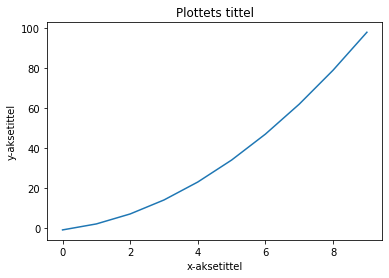

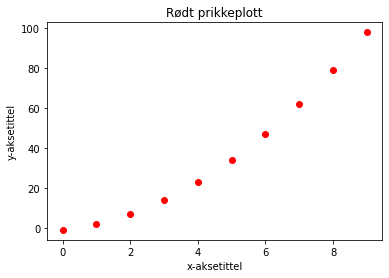

In [63]:
import matplotlib.pyplot as plt #Importer pyplot fra matplotlib og gi det synonymet plt

def andregradsfunksjon(x):
    return 2*x+x**2-1

x_liste = list(range(10))
y_liste = []
for x in x_liste:
    y_liste.append(andregradsfunksjon(x))
print(y_liste)

plt.plot(x_liste,y_liste,) #plot(«x-verdier», «y-verdier»)
plt.title("Plottets tittel")
plt.xlabel("x-aksetittel")
plt.ylabel("y-aksetittel")
plt.show()

#Dersom vi vil ha prikker:
plt.plot(x_liste,y_liste,'o', color='red') #plot(«x-verdier», «y-verdier»)
plt.title("Rødt prikkeplott")
plt.xlabel("x-aksetittel")
plt.ylabel("y-aksetittel")
plt.show()

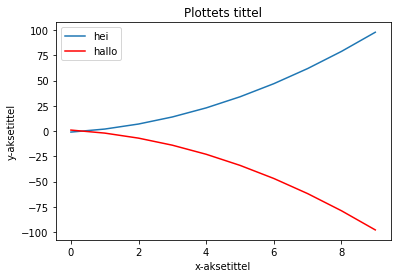

In [68]:
#Plotte flere grafer i samme plott
def f(x):
    return -andregradsfunksjon(x)
    
y2_liste = []
for x in x_liste:
    y2_liste.append(f(x))
    
plt.plot(x_liste,y_liste,label="hei") #label = "grafens navn"
plt.plot(x_liste,y2_liste, color='red', label="hallo") #color = "grafens farge"
plt.title("Plottets tittel")
plt.xlabel("x-aksetittel")
plt.ylabel("y-aksetittel")
plt.legend() #Lag boks med graftitler
plt.show()

# Litt numpy-tips
* Vi trenger kanskje å plotte en funksjon $f(x)$ for $x \in [0,1]$ og vil ha noen tusen datapunkter
* Da er det kjekt å bruke numpy!
* I numpy har vi ikke lister men *arrays*
* Forskjellen er:
  - Vi kan ikke blande forskjellige datatyper
  - listene kan ikke endre lengde (ingen pop() eller append()
* Fordelen er at vi med disse begresningene (+++) kan regne veldig raskt!

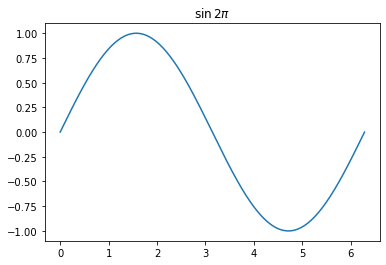

In [87]:
import numpy as np #importer numpy med synonym np

def g(x):
    return np.sin(x)

#Vi vil se på x-verdier mellom 0 og 2*pi 
#Vi vil bruke 10,000 datapunkter
n = 10000
x_start = 0
x_stop = 2*np.pi

#Vi kan lage "x-verdier" i numpy med np.arange eller np.linspace
x1 = np.arange(x_start, x_stop, 0.1) #arange gir et array med tall mellom start og stop, og lengde 0.1 mellom datapunkter
x = np.linspace(x_start,x_stop,n) #linspace gir n datapunkter mellom start og stop

y=g(x) #Når vi bruker numpy-arrays python at vi vil ha et array y med elementer g(x) 
plt.plot(x,y)
plt.title(r"$\sin{2\pi}$") # r"$«latexmatteuttrykk»$" 
plt.show()


# Populasjonvekst eksempel
Vi undersøker populasjonsvekst i skandinavia og plotter utviklingen de neste 20 årene

201
201


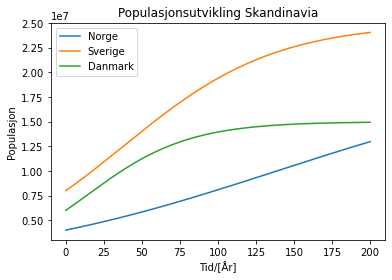

In [104]:
import math
import matplotlib.pyplot as plt
land = ["Norge", "Sverige", "Danmark"]
K = [20e6, 25e6, 15e6] #Makspopulasjon
r = [0.01, 0.02, 0.03] #relativ vekstrate
P0 = [4e6, 8e6, 6e6] # Startpopulasjon
t = 200 #Hvor mange år vekst


def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P

def lag_pop_funk(P0,K,r):
    def slutt_populasjon(t):
        P = logistisk_vekst(P0,K,r,t)
        return P
    return slutt_populasjon #Vi returnerer funksjonen vi laget inne i funksjonen!

def format_pop(P):
    return int(round(P,-3))

pop_lister = [] #Liste med populasjonsutvikling for landene
N_land = len(land) #Antall land (lengde på parameterlister)
t_liste = list(range(1,t+1)) #Liste fra og med 1, til og med t

for i in range(N_land): #for i = 0,1,2
    pop_funk = lag_pop_funk(P0[i], K[i], r[i])
    populasjon_liste = [P0[i]] #Lag ny liste med startpopulasjon
    for aar in t_liste: #For alle år i t_liste (1,2,3....
        populasjon = pop_funk(aar) #Regn ut populasjon i år 1,2,3,....
        populasjon_liste.append(populasjon) #Legg til denne populasjon bakerst i listen
    pop_lister.append(populasjon_liste) #Legg den ferdig utfylte listen i listen med populasjonslister

t_liste.insert(0,0) #Legg inn år 0 i start av liste
print(len(t_liste))
print(len(pop_lister[1]))

plt.title("Populasjonsutvikling Skandinavia")
plt.xlabel("Tid/[År]")
plt.ylabel("Populasjon")
for i,l in enumerate(land): #Iterer over land med indeks (0, "norge"), (1, "Sverige")...
    plt.plot(t_liste, pop_lister[i], label=l)
plt.legend()
plt.show()
    